In [1]:
# =========================================
# Heart Disease 데이터: Logistic Regression
# 성능 평가 + 중요 변수 추출 + 막대그래프
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score
)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# -----------------------------
# 1. 데이터 불러오기
# -----------------------------
df = pd.read_csv("heart.csv")

print("데이터 크기:", df.shape)
print("\n컬럼명:")
print(df.columns.tolist())
print("\n처음 5행:")
print(df.head())

데이터 크기: (1025, 14)

컬럼명:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

처음 5행:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


데이터 크기: (1025, 14)

기초 통계:
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000 

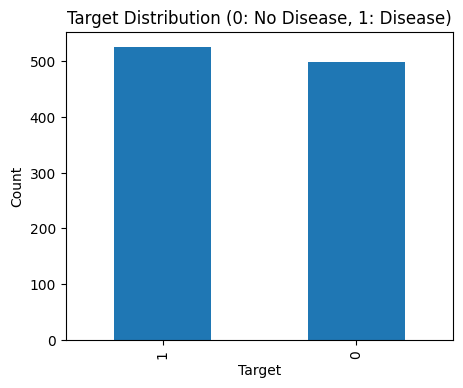

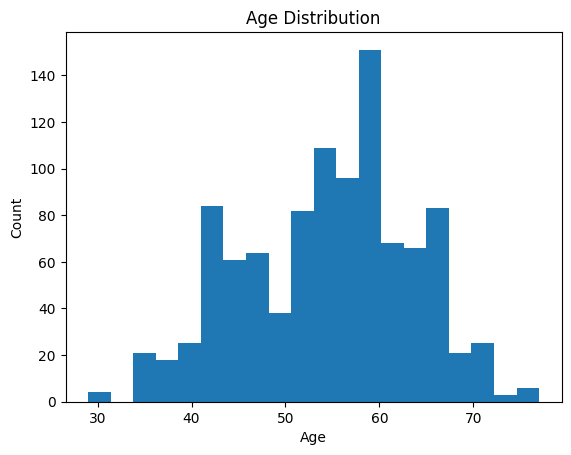

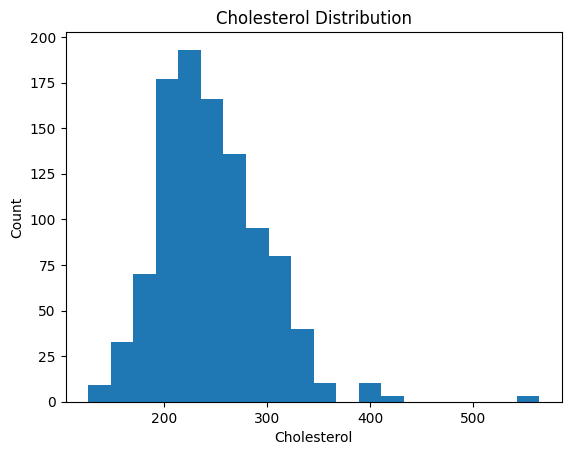

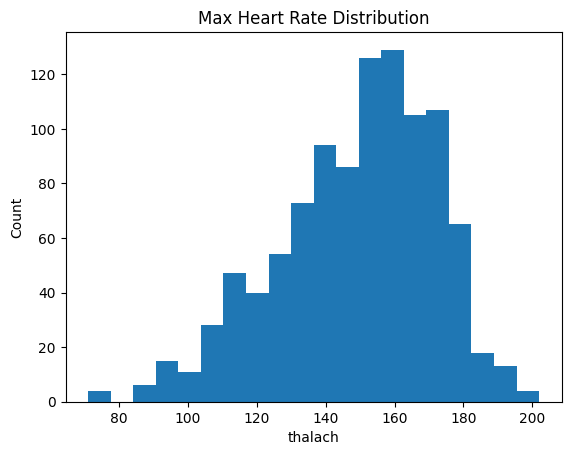

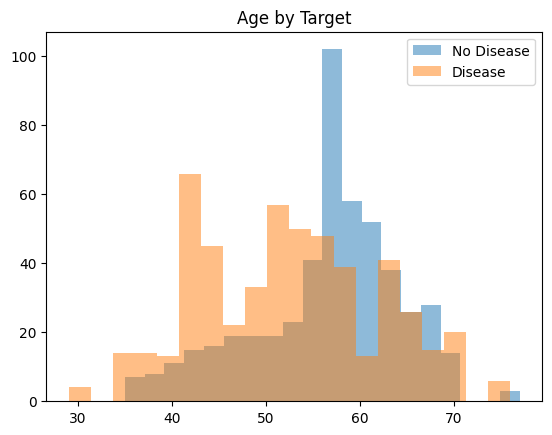

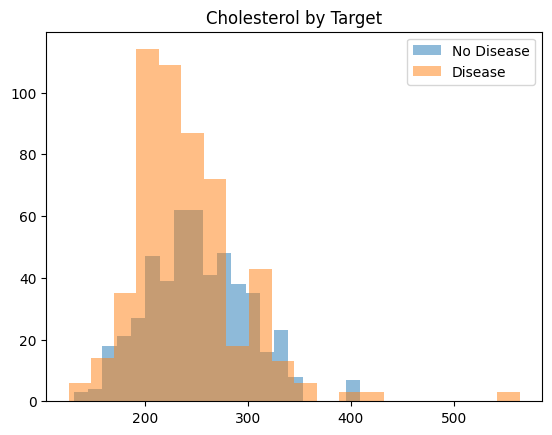

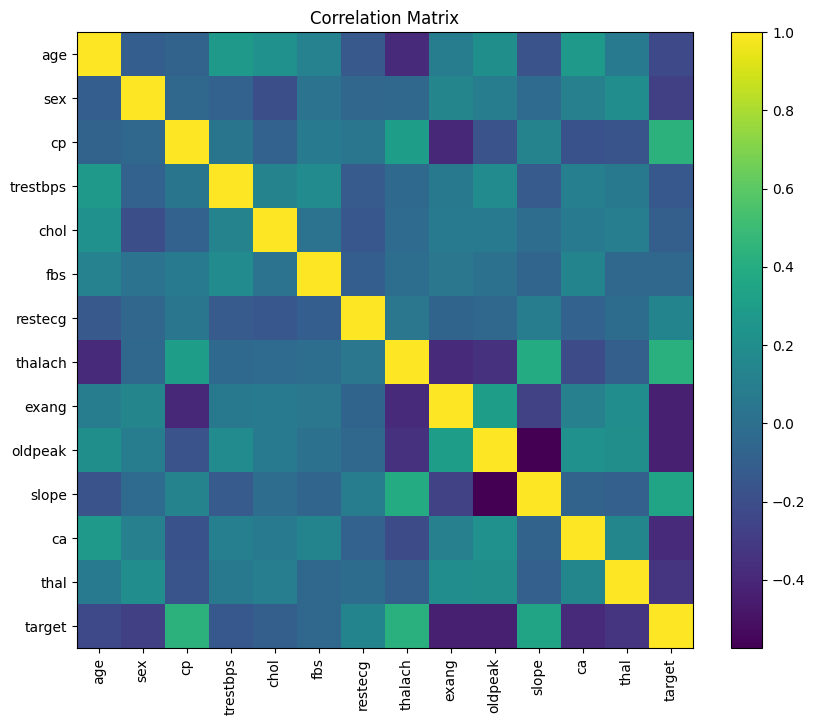


타깃과의 상관관계:
target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64


In [6]:
# -----------------------------
# 2. 기본 정보 확인
# -----------------------------
print("데이터 크기:", df.shape)

print("\n기초 통계:")
print(df.describe())

# -----------------------------
# 3. 결측치 확인
# -----------------------------
print("\n결측치 확인:")
print(df.isnull().sum())

# -----------------------------
# 4. 타깃 변수 분포
# -----------------------------
print("\n타깃 분포:")
print(df["target"].value_counts())

plt.figure(figsize=(5, 4))
df["target"].value_counts().plot(kind="bar")
plt.title("Target Distribution (0: No Disease, 1: Disease)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

# -----------------------------
# 5. 주요 변수 분포 확인
# -----------------------------
# 나이
plt.figure()
plt.hist(df["age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# 콜레스테롤
plt.figure()
plt.hist(df["chol"], bins=20)
plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Count")
plt.show()

# 최대 심박수
plt.figure()
plt.hist(df["thalach"], bins=20)
plt.title("Max Heart Rate Distribution")
plt.xlabel("thalach")
plt.ylabel("Count")
plt.show()

# -----------------------------
# 6. 타깃에 따른 비교
# -----------------------------
# 나이 vs 질병
plt.figure()
plt.hist(df[df["target"]==0]["age"], bins=20, alpha=0.5, label="No Disease")
plt.hist(df[df["target"]==1]["age"], bins=20, alpha=0.5, label="Disease")
plt.legend()
plt.title("Age by Target")
plt.show()

# 콜레스테롤 vs 질병
plt.figure()
plt.hist(df[df["target"]==0]["chol"], bins=20, alpha=0.5, label="No Disease")
plt.hist(df[df["target"]==1]["chol"], bins=20, alpha=0.5, label="Disease")
plt.legend()
plt.title("Cholesterol by Target")
plt.show()

# -----------------------------
# 7. 상관관계 확인
# -----------------------------
corr = df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

# -----------------------------
# 8. 타깃과의 상관관계만 보기
# -----------------------------
target_corr = corr["target"].sort_values(ascending=False)

print("\n타깃과의 상관관계:")
print(target_corr)

#상관관계가 크면 두 변수 중 하나만 쓰기

In [7]:
# -----------------------------
# 2. 입력변수(X), 타깃변수(y) 분리
# -----------------------------
X = df.drop("target", axis=1)
y = df["target"]

print("\n타깃 클래스 분포:")
print(y.value_counts())



타깃 클래스 분포:
target
1    526
0    499
Name: count, dtype: int64


In [8]:
# -----------------------------
# 3. 학습용 / 테스트용 데이터 분리
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
# -----------------------------
# 4. 표준화
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#선형 모델은 스케일링이 중요함 -> regression, SVM류
#트리계열 -> 의사결정 트리, 랜덤 포레스트, XGBoost, Light GBM

In [10]:
# -----------------------------
# 5. 로지스틱 회귀 모델 학습
# -----------------------------
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [11]:
# -----------------------------
# 6. 예측
# -----------------------------
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]


In [12]:
# -----------------------------
# 7. 성능 평가
# -----------------------------
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

In [13]:
print("\n===== Logistic Regression 성능 평가 =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred))



===== Logistic Regression 성능 평가 =====
Accuracy : 0.8098
Precision: 0.7619
Recall   : 0.9143
F1-score : 0.8312
ROC-AUC  : 0.9298

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



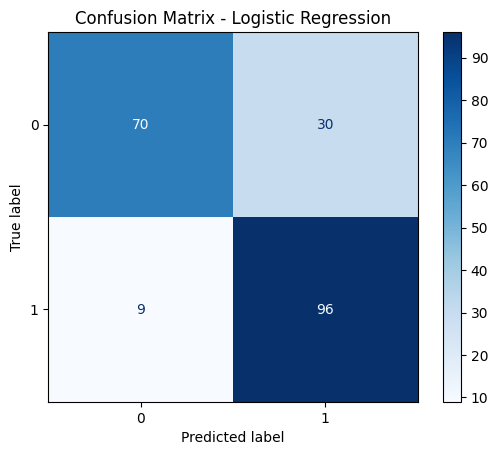

In [14]:
# -----------------------------
# 8. 혼동행렬 시각화
# -----------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

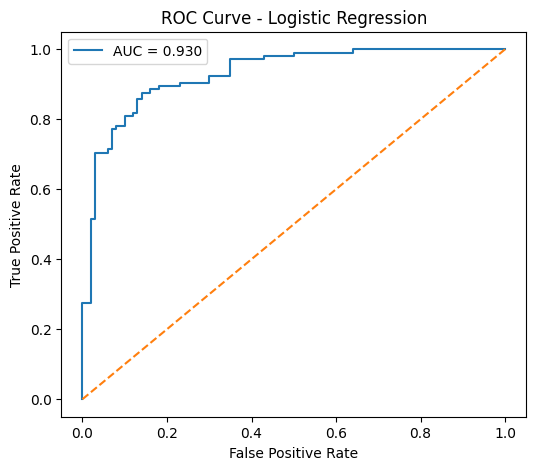

In [ ]:
# -----------------------------
# 9. ROC Curve 시각화
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [ ]:
# -----------------------------
# 10. 중요 변수 추출
# -----------------------------
# 로지스틱 회귀 계수(coefficient) 사용
coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients,
    "Abs_Coefficient": np.abs(coefficients)
})

# 절댓값 기준으로 정렬
feature_importance = feature_importance.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

print("\n===== 중요 변수 =====")
print(feature_importance)


===== 중요 변수 =====
     Feature  Coefficient  Abs_Coefficient
2         cp     0.867769         0.867769
1        sex    -0.781747         0.781747
11        ca    -0.745506         0.745506
9    oldpeak    -0.614295         0.614295
8      exang    -0.517055         0.517055
12      thal    -0.499174         0.499174
7    thalach     0.411778         0.411778
10     slope     0.365533         0.365533
3   trestbps    -0.362392         0.362392
4       chol    -0.275126         0.275126
6    restecg     0.163175         0.163175
0        age    -0.116839         0.116839
5        fbs    -0.016271         0.016271


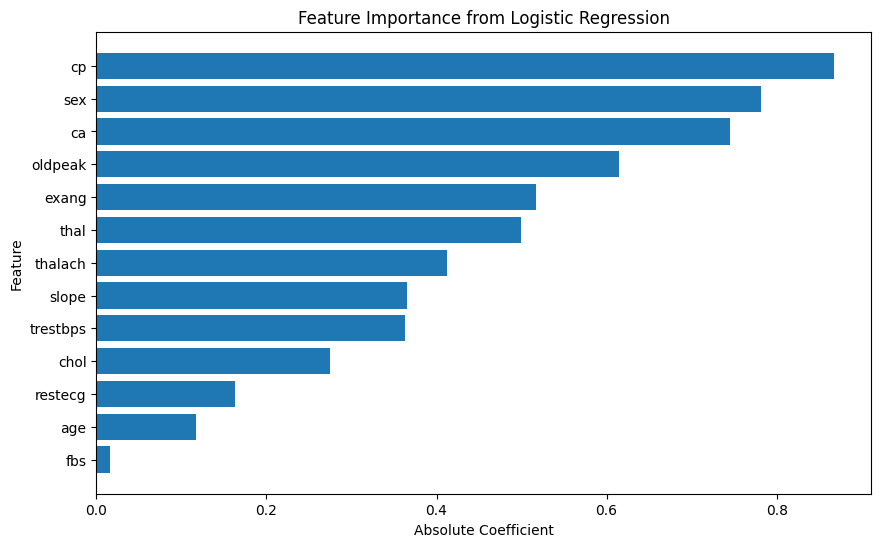

In [ ]:
# -----------------------------
# 11. 중요 변수 막대그래프
# -----------------------------
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Abs_Coefficient"])
plt.gca().invert_yaxis()
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Feature Importance from Logistic Regression")
plt.show()

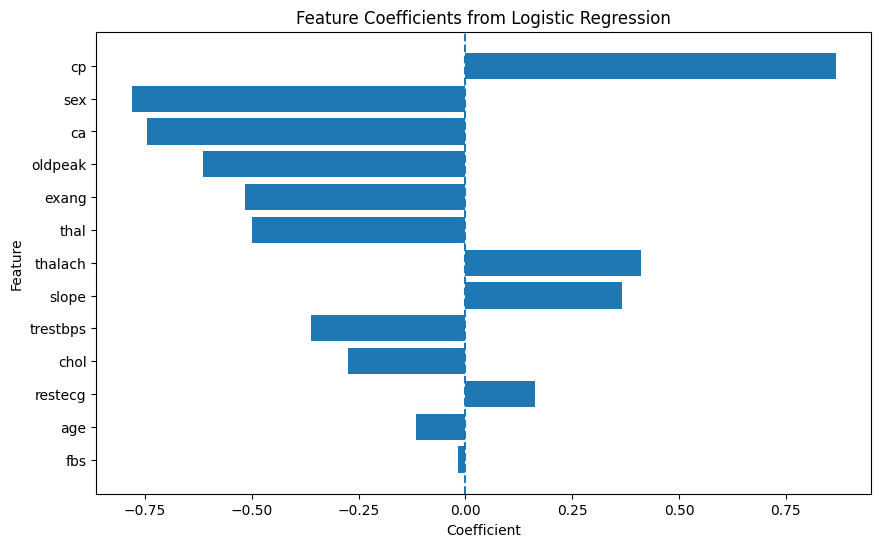

In [ ]:
# -----------------------------
# 12. 방향성까지 보고 싶을 때
# -----------------------------
# 계수가 +면 target=1일 가능성을 높이고
# 계수가 -면 target=1일 가능성을 낮춘다고 해석 가능
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Coefficient"])
plt.axvline(0, linestyle="--")
plt.gca().invert_yaxis()
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Feature Coefficients from Logistic Regression")
plt.show()

In [ ]:
from sklearn.svm import SVC
# -----------------------------
# 4. 표준화
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# -----------------------------
# 5. SVM 모델 학습
# -----------------------------
# probability=True 로 해야 ROC-AUC 계산 가능
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [ ]:
# -----------------------------
# 6. 예측
# -----------------------------
y_pred = svm_model.predict(X_test_scaled)
y_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

# -----------------------------
# 7. 성능 평가
# -----------------------------
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n===== SVM 성능 평가 =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred))



===== SVM 성능 평가 =====
Accuracy : 0.9268
Precision: 0.9167
Recall   : 0.9429
F1-score : 0.9296
ROC-AUC  : 0.9771

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       100
           1       0.92      0.94      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205



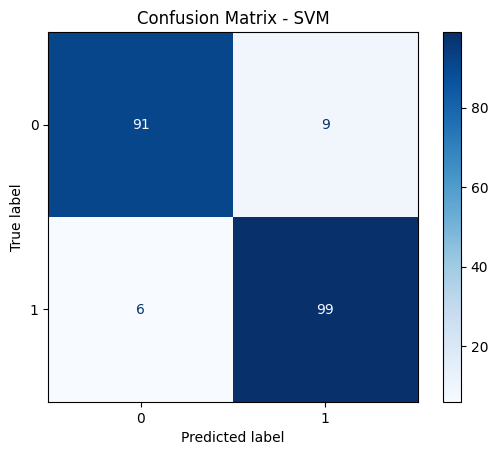

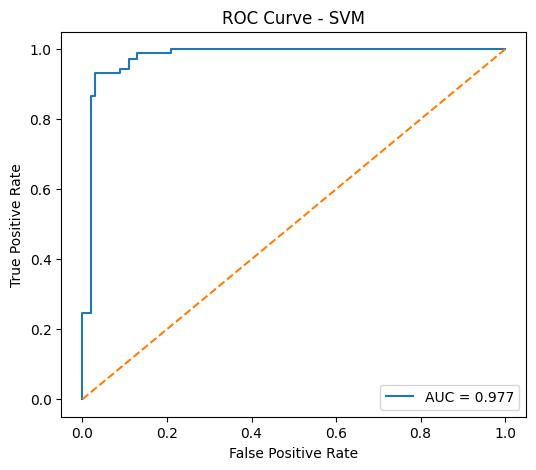

In [ ]:

# -----------------------------
# 8. 혼동행렬 시각화
# -----------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.show()

# -----------------------------
# 9. ROC Curve 시각화
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()


===== Decision Tree 성능 평가 =====
Accuracy : 0.8390
Precision: 0.8214
Recall   : 0.8762
F1-score : 0.8479
ROC-AUC  : 0.8957

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.86      0.80      0.83       100
           1       0.82      0.88      0.85       105

    accuracy                           0.84       205
   macro avg       0.84      0.84      0.84       205
weighted avg       0.84      0.84      0.84       205



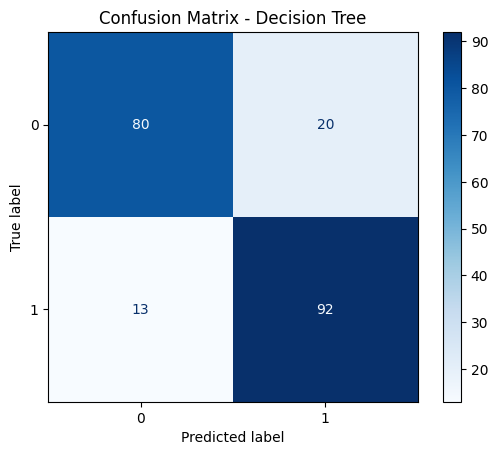

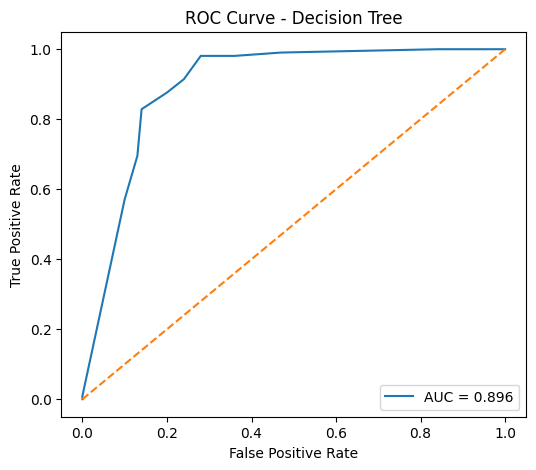


===== 변수 중요도 =====
     Feature  Importance
2         cp    0.435373
11        ca    0.123549
12      thal    0.103193
0        age    0.094111
4       chol    0.061523
9    oldpeak    0.057389
1        sex    0.053821
8      exang    0.039893
3   trestbps    0.031148
7    thalach    0.000000
6    restecg    0.000000
5        fbs    0.000000
10     slope    0.000000


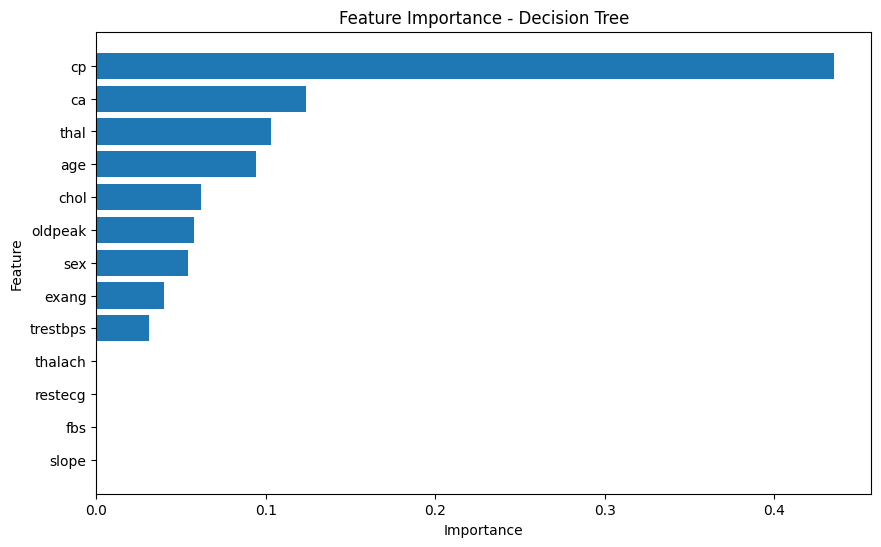

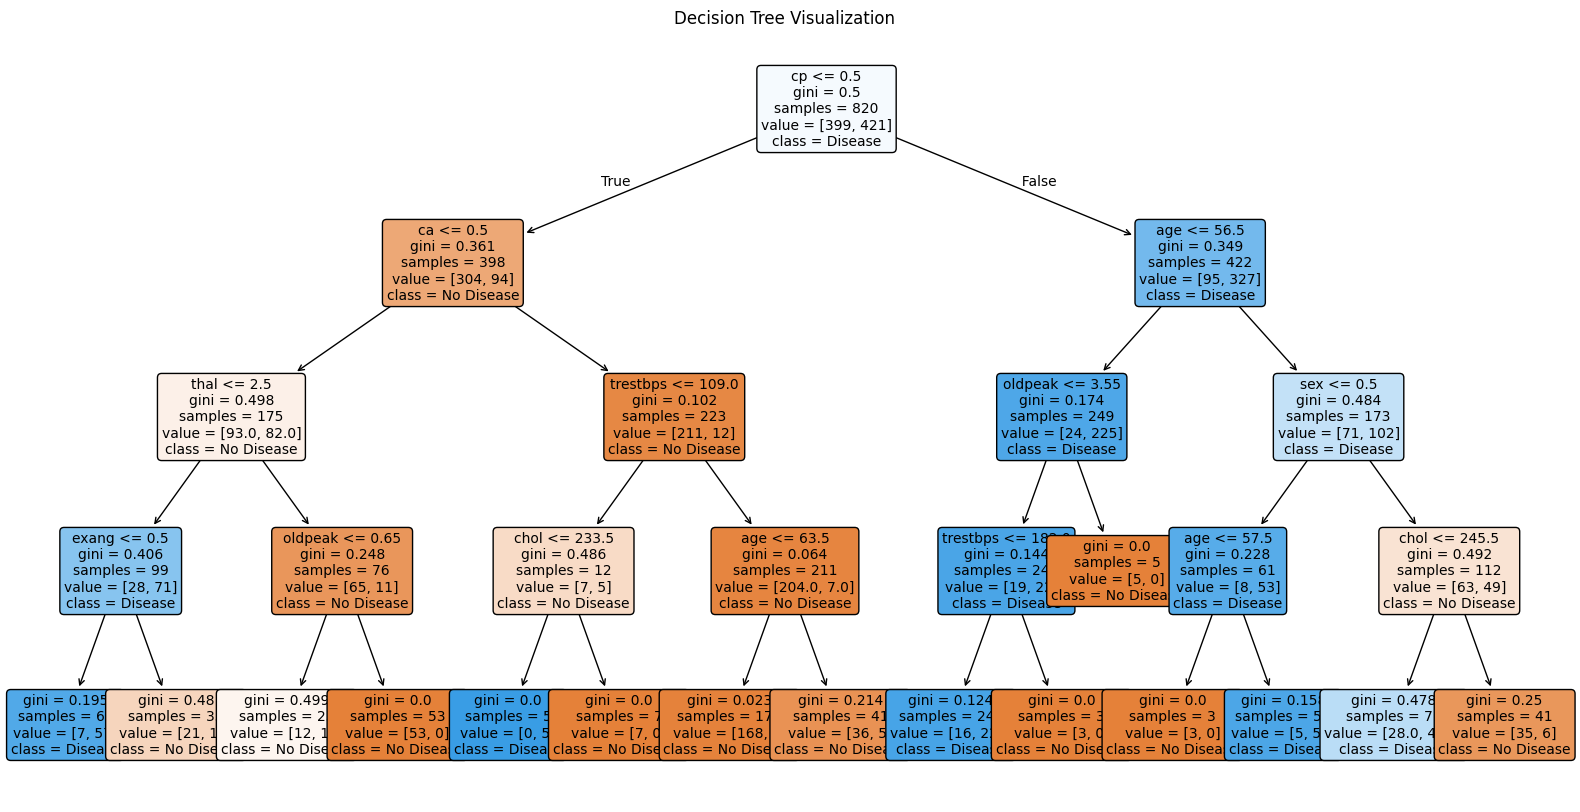

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# -----------------------------
# 2. 입력변수(X), 타깃변수(y) 분리
# -----------------------------
X = df.drop("target", axis=1)
y = df["target"]

# -----------------------------
# 3. 학습용 / 테스트용 데이터 분리
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# 4. 의사결정트리 모델 학습
# -----------------------------
# max_depth를 제한하면 시각화가 훨씬 보기 쉬워집니다.
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train, y_train)

# -----------------------------
# 5. 예측
# -----------------------------
y_pred = tree_model.predict(X_test)
y_prob = tree_model.predict_proba(X_test)[:, 1]

# -----------------------------
# 6. 성능 평가
# -----------------------------
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n===== Decision Tree 성능 평가 =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred))

# -----------------------------
# 7. 혼동행렬 시각화
# -----------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# -----------------------------
# 8. ROC Curve 시각화
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

# -----------------------------
# 9. 변수 중요도 확인
# -----------------------------
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n===== 변수 중요도 =====")
print(importance_df)

# 변수 중요도 막대그래프
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Decision Tree")
plt.show()

# -----------------------------
# 10. 의사결정트리 시각화
# -----------------------------
plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization")
plt.show()


===== Random Forest 성능 평가 =====
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
ROC-AUC  : 1.0000

===== Classification Report =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



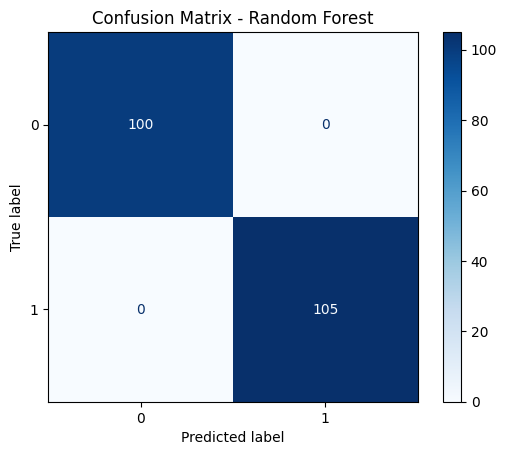

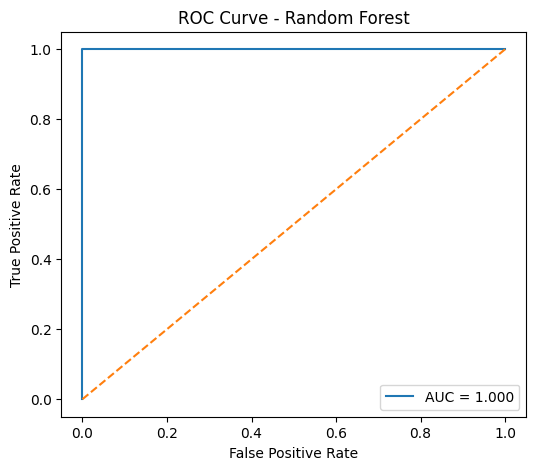


===== 변수 중요도 =====
     Feature  Importance
2         cp    0.144796
7    thalach    0.118097
11        ca    0.110965
9    oldpeak    0.105590
12      thal    0.101825
0        age    0.091826
4       chol    0.076579
8      exang    0.074189
3   trestbps    0.071178
10     slope    0.045234
1        sex    0.029885
6    restecg    0.019166
5        fbs    0.010670


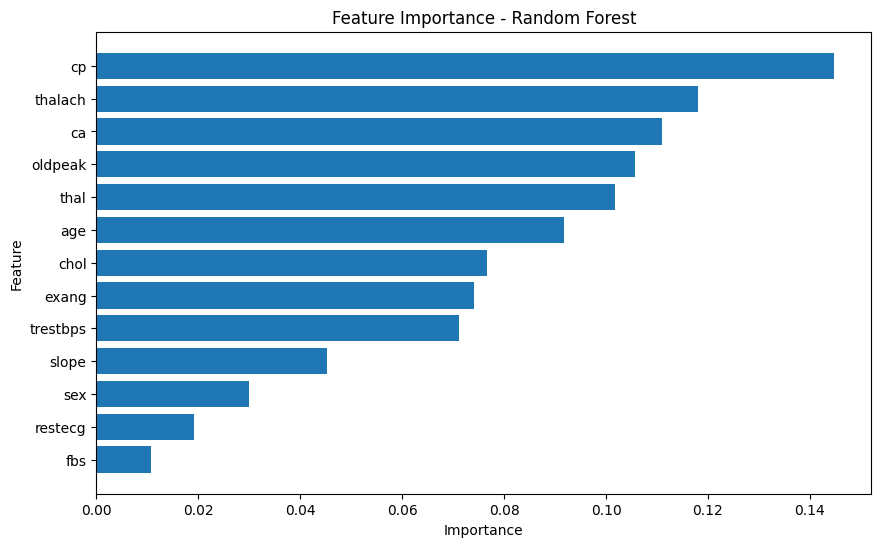

In [ ]:
# -----------------------------
# 4. 랜덤포레스트 모델 학습
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

# -----------------------------
# 5. 예측
# -----------------------------
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# -----------------------------
# 6. 성능 평가
# -----------------------------
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n===== Random Forest 성능 평가 =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred))

# -----------------------------
# 7. 혼동행렬 시각화
# -----------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# -----------------------------
# 8. ROC Curve 시각화
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

# -----------------------------
# 9. 변수 중요도 추출
# -----------------------------
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n===== 변수 중요도 =====")
print(importance_df)

# -----------------------------
# 10. 변수 중요도 막대그래프
# -----------------------------
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.show()


===== XGBoost 성능 평가 =====
Accuracy : 0.9805
Precision: 0.9810
Recall   : 0.9810
F1-score : 0.9810
ROC-AUC  : 0.9996

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       100
           1       0.98      0.98      0.98       105

    accuracy                           0.98       205
   macro avg       0.98      0.98      0.98       205
weighted avg       0.98      0.98      0.98       205



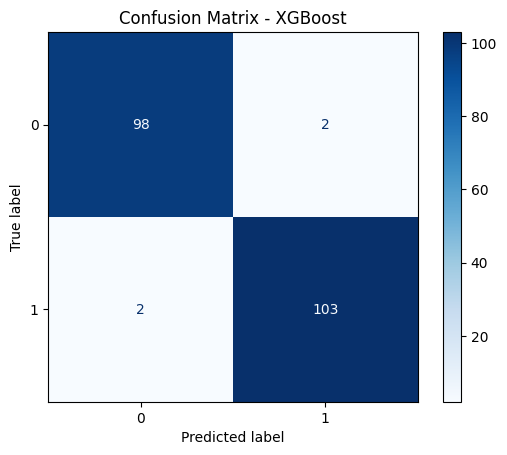

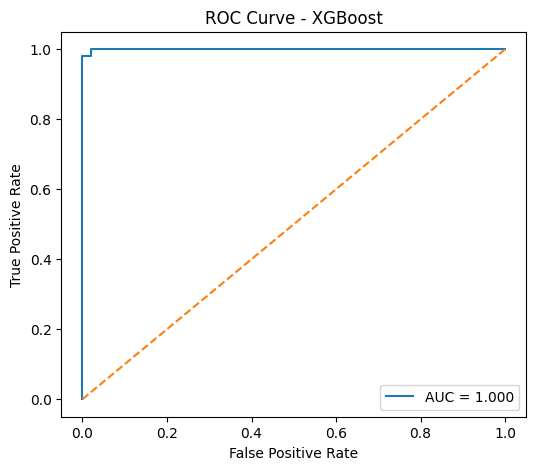


===== 변수 중요도 =====
     Feature  Importance
2         cp    0.239521
8      exang    0.138425
11        ca    0.114504
12      thal    0.110120
1        sex    0.062246
9    oldpeak    0.062049
10     slope    0.059440
0        age    0.042541
6    restecg    0.041333
7    thalach    0.037222
4       chol    0.035906
3   trestbps    0.034615
5        fbs    0.022078


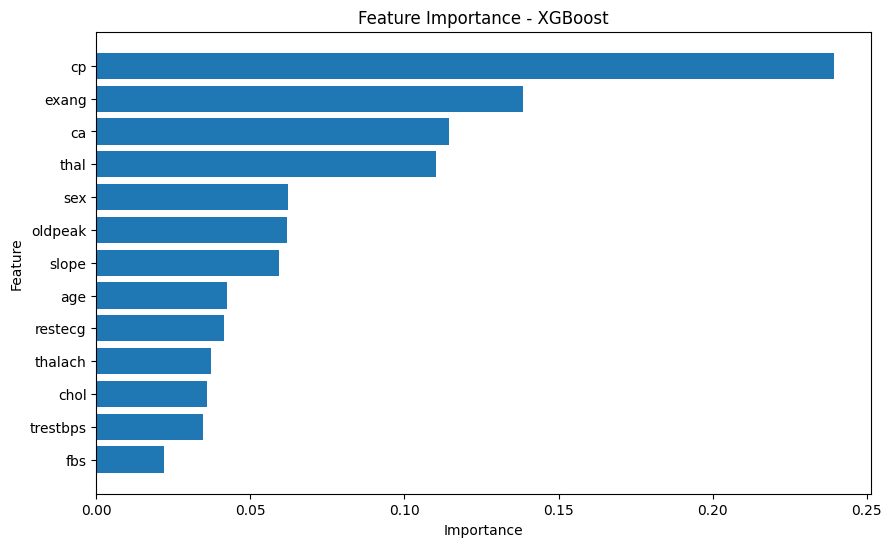

In [ ]:
from xgboost import XGBClassifier

# -----------------------------
# 4. XGBoost 모델 학습
# -----------------------------
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

# -----------------------------
# 5. 예측
# -----------------------------
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# -----------------------------
# 6. 성능 평가
# -----------------------------
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n===== XGBoost 성능 평가 =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred))

# -----------------------------
# 7. 혼동행렬 시각화
# -----------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.show()

# -----------------------------
# 8. ROC Curve 시각화
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

# -----------------------------
# 9. 변수 중요도 추출
# -----------------------------
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n===== 변수 중요도 =====")
print(importance_df)

# -----------------------------
# 10. 변수 중요도 막대그래프
# -----------------------------
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - XGBoost")
plt.show()

In [ ]:
!pip install lightgbm


===== LightGBM 성능 평가 =====
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-score : 1.0000
ROC-AUC  : 1.0000

===== Classification Report =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



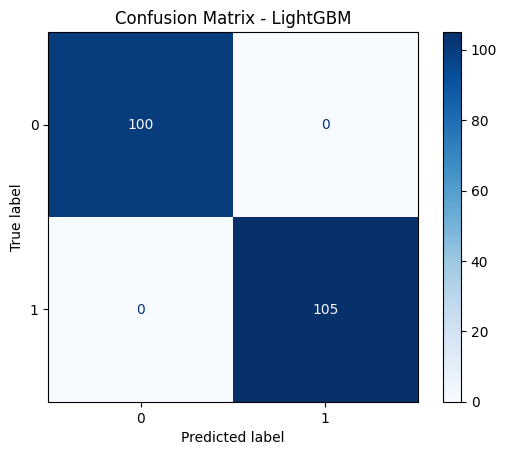

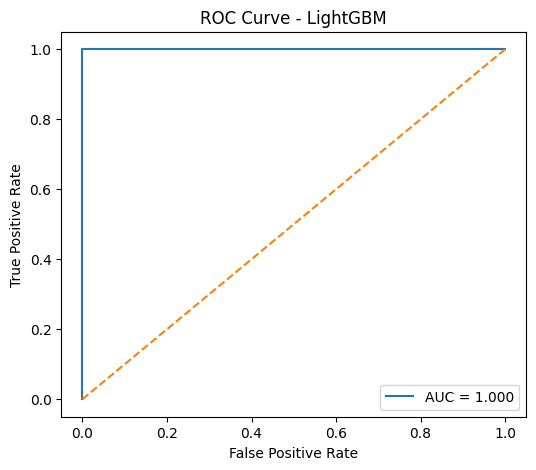


===== 변수 중요도 =====
     Feature  Importance
4       chol        1008
0        age         927
7    thalach         848
9    oldpeak         713
3   trestbps         622
2         cp         427
11        ca         352
12      thal         312
6    restecg         198
8      exang         176
1        sex         166
10     slope         120
5        fbs          48


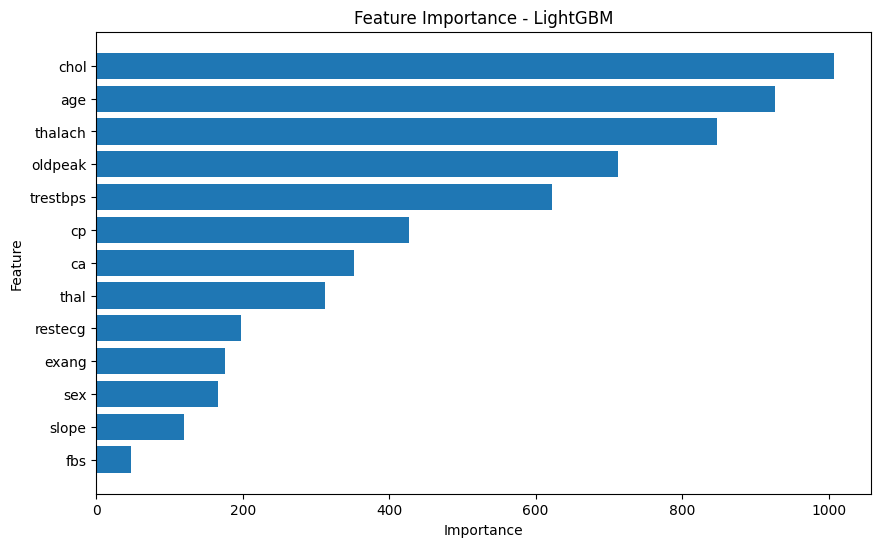

In [ ]:
from lightgbm import LGBMClassifier

# -----------------------------
# 4. LightGBM 모델 학습
# -----------------------------
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)

# -----------------------------
# 5. 예측
# -----------------------------
y_pred = lgbm_model.predict(X_test)
y_prob = lgbm_model.predict_proba(X_test)[:, 1]

# -----------------------------
# 6. 성능 평가
# -----------------------------
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n===== LightGBM 성능 평가 =====")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred))

# -----------------------------
# 7. 혼동행렬 시각화
# -----------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - LightGBM")
plt.show()

# -----------------------------
# 8. ROC Curve 시각화
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM")
plt.legend()
plt.show()

# -----------------------------
# 9. 변수 중요도 추출
# -----------------------------
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": lgbm_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n===== 변수 중요도 =====")
print(importance_df)

# -----------------------------
# 10. 변수 중요도 막대그래프
# -----------------------------
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - LightGBM")
plt.show()